In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkb

from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
citylondon_17 = pd.read_csv('data_source/period-2010-to-2017-E09000001-city of london.csv')
camden_17 = pd.read_csv('data_source/period-2010-to-2017-E09000007-camden.csv')
hackney_17 = pd.read_csv('data_source/period-2010-to-2017-E09000012-hackney.csv')
westminster_17 = pd.read_csv('data_source/period-2010-to-2017-E09000033-westminster.csv')

In [4]:
# 读取shp文件
citylondon_lsoa = gpd.read_file('data_source/LB_shp/City of London.shp')
camden_lsoa = gpd.read_file('data_source/LB_shp/Camden.shp')
hackney_lsoa = gpd.read_file('data_source/LB_shp/Hackney.shp')
westminster_lsoa = gpd.read_file('data_source/LB_shp/Westminster.shp')

In [6]:
# Cleaning
citylondon_17N = citylondon_17[citylondon_17['rateable_value'] > 0]  # Remove outliers
citylondon_17N = citylondon_17N.dropna(subset=['rateable_value'])

camden_17N = camden_17[camden_17['rateable_value'] > 0]
camden_17N = camden_17N.dropna(subset=['rateable_value'])

hackney_17N = hackney_17[hackney_17['rateable_value'] > 0]
hackney_17N = hackney_17N.dropna(subset=['rateable_value'])

westminster_17N = westminster_17[westminster_17['rateable_value'] > 0]
westminster_17N = westminster_17N.dropna(subset=['rateable_value'])

# Convert WKB geometry to Shapely objects
citylondon_17N['geom'] = citylondon_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
camden_17N['geom'] = camden_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
hackney_17N['geom'] = hackney_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
westminster_17N['geom'] = westminster_17N['geometry'].apply(lambda x: wkb.loads(x, hex=True))

In [7]:
# import the data
citylondon_23 = pd.read_csv('data_source/period-2017-to-2023-E09000001-city of london.csv')
camden_23 = pd.read_csv('data_source/period-2017-to-2023-E09000007-camden.csv')
hackney_23 = pd.read_csv('data_source/period-2017-to-2023-E09000012-hackney.csv')
westminster_23 = pd.read_csv('data_source/period-2017-to-2023-E09000033-westminster.csv')

# Cleaning
citylondon_23N = citylondon_23[citylondon_23['rateable_value'] > 0]  # Remove outliers
citylondon_23N = citylondon_23N.dropna(subset=['rateable_value'])

camden_23N = camden_23[camden_23['rateable_value'] > 0]
camden_23N = camden_23N.dropna(subset=['rateable_value'])

hackney_23N = hackney_23[hackney_23['rateable_value'] > 0]
hackney_23N = hackney_23N.dropna(subset=['rateable_value'])

westminster_23N = westminster_23[westminster_23['rateable_value'] > 0]
westminster_23N = westminster_23N.dropna(subset=['rateable_value'])

# Convert WKB geometry to Shapely objects
citylondon_23N['geom'] = citylondon_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
camden_23N['geom'] = camden_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
hackney_23N['geom'] = hackney_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))
westminster_23N['geom'] = westminster_23N['geometry'].apply(lambda x: wkb.loads(x, hex=True))

In [8]:
def spatial_join_companies_lsoa(df_companies, gdf_lsoa, geometry_col='geom'):
    # 创建GeoDataFrame
    gdf_companies = gpd.GeoDataFrame(df_companies, geometry=geometry_col)
    gdf_companies.set_crs('EPSG:4326', inplace=True, allow_override=True)
    
    # 统一CRS
    if gdf_companies.crs != gdf_lsoa.crs:
        gdf_companies = gdf_companies.to_crs(gdf_lsoa.crs)
    
    # 进行空间连接 - 将点数据与包含它们的多边形连接
    merged_data = gpd.sjoin(gdf_companies, gdf_lsoa, how='left', predicate='within')
    
    return merged_data

In [9]:
citylondon_17M = spatial_join_companies_lsoa(citylondon_17N, citylondon_lsoa)
camden_17M = spatial_join_companies_lsoa(camden_17N, camden_lsoa)
hackney_17M = spatial_join_companies_lsoa(hackney_17N, hackney_lsoa)
westminster_17M = spatial_join_companies_lsoa(westminster_17N, westminster_lsoa)

In [10]:
# 合并四个区域的数据
business17 = pd.concat([
    citylondon_17M,
    camden_17M,
    hackney_17M,
    westminster_17M
], ignore_index=True)

In [11]:
def add_timepoint_field(gdf, revaluation_year='2017'):
    """
    根据series和epoch列的组合添加timepoint字段
    """
    import numpy as np  # 确保导入numpy
    
    if revaluation_year == '2017':
        conditions = [
            (gdf['series'] == 2010) & (gdf['epoch'] == 21),
            (gdf['series'] == 2010) & (gdf['epoch'] == 23),
            (gdf['series'] == 2017) & (gdf['epoch'] == 2),
            (gdf['series'] == 2017) & (gdf['epoch'] == 4),
            (gdf['series'] == 2017) & (gdf['epoch'] == 7),
            (gdf['series'] == 2017) & (gdf['epoch'] == 13)
        ]
    elif revaluation_year == '2023':  # 确保这里是字符串比较
        conditions = [
            (gdf['series'] == 2017) & (gdf['epoch'] == 32),
            (gdf['series'] == 2017) & (gdf['epoch'] == 34),
            (gdf['series'] == 2023) & (gdf['epoch'] == 2),
            (gdf['series'] == 2023) & (gdf['epoch'] == 5),
            (gdf['series'] == 2023) & (gdf['epoch'] == 8),
            (gdf['series'] == 2023) & (gdf['epoch'] == 15)
        ]
    else:
        print(f"未识别的revaluation_year: {revaluation_year}")
        return gdf
    
    timepoint_labels = ['-12', '-6', '0', '+6', '+12', '+24']
    gdf['timepoint'] = np.select(conditions, timepoint_labels, default='other')
    
    return gdf

In [19]:
business17_with_timepoint = add_timepoint_field(business17, revaluation_year='2017')
print(business17_with_timepoint['timepoint'].value_counts())

timepoint
+24      86991
other    86007
+12      85115
+6       84300
-12      84002
-6       83844
0        82715
Name: count, dtype: int64


In [64]:
business23.columns

Index(['filter_period', 'billing_authority_name', 'geocode', 'uarn',
       'billing_reference', 'account_name', 'account_start_date',
       'searchable_address', 'postcode_id', 'geometry', 'occupation_state',
       'occupation_date', 'category_id', 'primary_description',
       'category_subgroup', 'category_group', 'rates_payable',
       'rateable_value', 'total_floor_area', 'unit_of_measure', 'from_date',
       'record_date', 'series', 'epoch', 'geom', 'index_right', 'lsoa21cd',
       'lsoa21nm', 'msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm', 'timepoint'],
      dtype='object')

In [12]:
citylondon_23M = spatial_join_companies_lsoa(citylondon_23N, citylondon_lsoa)
camden_23M = spatial_join_companies_lsoa(camden_23N, camden_lsoa)
hackney_23M = spatial_join_companies_lsoa(hackney_23N, hackney_lsoa)
westminster_23M = spatial_join_companies_lsoa(westminster_23N, westminster_lsoa)

In [13]:
# 合并四个区域的数据
business23 = pd.concat([
    citylondon_23M,
    camden_23M,
    hackney_23M,
    westminster_23M
], ignore_index=True)

In [72]:
business23_with_timepoint = add_timepoint_field(business23, revaluation_year='2023')
print(business23_with_timepoint['timepoint'].value_counts())

timepoint
-12      88875
-6       88422
0        86491
+6       85143
+12      84207
+24      84118
other    83973
Name: count, dtype: int64


In [21]:
# 1. 数据预处理
def preprocess_data(business17, revaluation_year='2017'):
    """数据清洗和预处理"""
    df = business17.copy()
    
    # 首先添加时间节点字段
    df = add_timepoint_field(df, revaluation_year=revaluation_year)  # 添加参数
    
    # 过滤出有效的时间点
    df = df[df['timepoint'] != 'other']
    
    # 处理缺失值和异常值
    df = df.replace('#######', np.nan)
    df = df.replace('########', np.nan)
    
    # 转换数据类型
    numeric_cols = ['rateable_value', 'total_floor_area', 'rates_payable']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 删除关键变量缺失的观测
    df = df.dropna(subset=['rateable_value', 'lsoa21cd', 'timepoint'])
    
    # 处理异常值（Winsorizing）
    for col in numeric_cols:
        if col in df.columns:
            q01 = df[col].quantile(0.01)
            q99 = df[col].quantile(0.99)
            df[col] = df[col].clip(lower=q01, upper=q99)
    
    # 创建时间相关变量
    df['timepoint_numeric'] = df['timepoint'].astype(int)  # 转换为数值便于回归
    
    # 创建treatment变量 (时间点0及以后为treatment期)
    df['post_2017'] = (df['timepoint_numeric'] >= 0).astype(int)
    
    # 创建相对时间变量
    df['months_from_treatment'] = df['timepoint_numeric']

    # 添加bunching分析变量
    df['threshold_15k'] = (df['rateable_value'] >= 14500) & (df['rateable_value'] <= 15500)
    df['near_threshold'] = (df['rateable_value'] >= 10000) & (df['rateable_value'] <= 25000)
    df['below_threshold'] = (df['rateable_value'] < 15000).astype(int)
    
    # 创建rateable value bins (£500间隔)
    df['rv_bin'] = (df['rateable_value'] // 500) * 500
    df['distance_to_threshold'] = df['rateable_value'] - 15000
    
    print("时间点分布:")
    print(df['timepoint'].value_counts().sort_index())
    
    return df

def bunching_analysis(df_clean):
    """分析15000阈值附近的bunching现象"""
    
    # 过滤到阈值附近的数据
    threshold_data = df_clean[
        (df_clean['rateable_value'] >= 10000) & 
        (df_clean['rateable_value'] <= 25000)
    ].copy()
    
    # 按时期和bin计算密度
    density_analysis = threshold_data.groupby(['timepoint', 'rv_bin']).agg({
        'lsoa21cd': 'count',
        'rateable_value': 'mean'
    }).rename(columns={'lsoa21cd': 'property_count'}).reset_index()
    
    # 计算总密度用于标准化
    total_by_period = density_analysis.groupby('timepoint')['property_count'].sum()
    density_analysis['density'] = density_analysis.apply(
        lambda x: x['property_count'] / total_by_period[x['timepoint']], axis=1
    )
    
    return density_analysis

def estimate_bunching_model(df_clean):
    """估计bunching效应模型"""
    
    # 过滤到阈值附近
    bunching_panel =df_clean[df_clean['near_threshold'] == True].copy()
    
    # Bunching强度模型
    formula_bunching = """density ~ post_2017 * threshold_15k + 
                         C(timepoint) + C(rv_bin) - 1"""
    
    try:
        bunching_model = ols(formula_bunching, data=bunching_panel).fit()
        print("=== Bunching Analysis Results ===")
        print(bunching_model.summary().tables[1])
        
        return bunching_model
    except Exception as e:
        print(f"Bunching model error: {e}")
        return None

def estimate_threshold_response_model(panel):
    """估计阈值响应模型"""
    
    # 阈值附近的物业
    threshold_panel = panel[panel['near_threshold'] == True].copy()
    
    # 低于阈值概率模型
    formula_threshold = """below_threshold ~ post_2017 * near_threshold + 
                          log_floor_area + log_property_count +
                          C(lsoa21cd) + C(timepoint) - 1"""
    
    try:
        threshold_model = ols(formula_threshold, data=threshold_panel).fit()
        print("=== Threshold Response Results ===") 
        print(threshold_model.summary().tables[1])
        
        return threshold_model
    except Exception as e:
        print(f"Threshold model error: {e}")
        return None

# 2. 构建面板数据
def create_panel_data(df):
    """构建LSOA层面的面板数据"""
    
    # LSOA层面聚合
    panel_vars = {
        'rateable_value': ['sum', 'mean', 'count'],
        'total_floor_area': ['sum', 'mean'],
        'rates_payable': ['sum', 'mean']
    }
    
    # 按LSOA和时间点聚合
    panel = df.groupby(['lsoa21cd', 'timepoint']).agg({
        'rateable_value': ['sum', 'mean', 'count'],
        'total_floor_area': ['sum', 'mean'], 
        'rates_payable': ['sum', 'mean'],
        'category_group': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'UNKNOWN',
        'post_2017': 'first',
        'timepoint_numeric': 'first',
        'months_from_treatment': 'first'
    }).reset_index()
    
    # 扁平化列名
    panel.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] 
                    for col in panel.columns]
    
    # 重命名关键列
    panel = panel.rename(columns={
        'rateable_value_sum': 'rateable_value',
        'rateable_value_mean': 'avg_rateable_value', 
        'rateable_value_count': 'property_count',
        'total_floor_area_sum': 'total_floor_area',
        'total_floor_area_mean': 'avg_floor_area',
        'rates_payable_sum': 'total_rates',
        'category_group_<lambda>': 'dominant_category',
        'timepoint_numeric_': 'timepoint_numeric',
        'months_from_treatment_': 'months_from_treatment',
        'post_2017_first': 'post_2017',
        'timepoint_numeric_first': 'timepoint_numeric',        # 添加这行
        'months_from_treatment_first': 'months_from_treatment'  # 添加这行
    })
    
    # 创建对数变量
    panel['log_rateable_value'] = np.log(panel['rateable_value'] + 1)
    panel['log_floor_area'] = np.log(panel['total_floor_area'] + 1)
    panel['log_property_count'] = np.log(panel['property_count'])

    print("Columns after aggregation:", panel.columns.tolist())
    return panel
    

# 3. 创建虚拟变量
def create_dummy_variables(panel):
    """创建时间和物业类型虚拟变量"""
    
    # 时间虚拟变量（以-12为基期，即2016-06-30）
    time_dummies = pd.get_dummies(panel['timepoint'], prefix='time')
    time_base = 'time_-12'
    if time_base in time_dummies.columns:
        time_dummies = time_dummies.drop(columns=[time_base])
    
    # 物业类型虚拟变量
    category_dummies = pd.get_dummies(panel['dominant_category'], prefix='category')
    
    # 合并虚拟变量
    panel_with_dummies = pd.concat([panel, time_dummies, category_dummies], axis=1)
    
    return panel_with_dummies

# 4. 基准模型估计
def estimate_baseline_model(panel):
    """估计基准面板回归模型"""
    
    # 准备回归变量 - 使用时间点作为连续变量和虚拟变量
    formula = """log_rateable_value ~ post_2017 + months_from_treatment + log_floor_area + log_property_count + 
                 C(lsoa21cd) + C(timepoint) - 1"""
    
    try:
        # OLS估计
        model = ols(formula, data=panel).fit(
            cov_type='cluster', 
            cov_kwds={'groups': panel['lsoa21cd']}
        )
        
        print("=== 基准模型估计结果 ===")
        print(model.summary().tables[1])
        
        return model
    
    except Exception as e:
        print(f"模型估计错误: {e}")
        return None

# 5. 异质性交互效应模型
def estimate_interaction_model(panel):
    """估计异质性交互效应模型"""
    
    # 创建交互项
    area_cols = [col for col in panel.columns if col.startswith('area_')]
    category_cols = [col for col in panel.columns if col.startswith('category_')]
    
    
    for cat_col in category_cols[:5]:  # 限制类别数量避免过拟合
        panel[f'{cat_col}_post2017'] = panel[cat_col] * panel['post_2017']
    
    # 交互效应模型公式
    interaction_terms = " + ".join([f'{col}_post2017' for col in category_cols[:5]])
    
    formula = f"""log_rateable_value ~ post_2017 + {interaction_terms} + 
                  log_floor_area + log_property_count + 
                  C(lsoa21cd) + C(timepoint) - 1"""
    
    try:
        model_interaction = ols(formula, data=panel).fit(
            cov_type='cluster', 
            cov_kwds={'groups': panel['lsoa21cd']}
        )
        
        print("\n=== 交互效应模型估计结果 ===")
        print(model_interaction.summary().tables[1])
        
        return model_interaction
        
    except Exception as e:
        print(f"交互模型估计错误: {e}")
        return None

# 6. 模型诊断
def model_diagnostics(model, panel):
    """模型诊断和稳健性检验"""
    
    if model is None:
        return
    
    # 残差分析
    residuals = model.resid
    fitted_values = model.fittedvalues
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 残差vs拟合值
    axes[0,0].scatter(fitted_values, residuals, alpha=0.5)
    axes[0,0].axhline(y=0, color='red', linestyle='--')
    axes[0,0].set_xlabel('Fitted Values')
    axes[0,0].set_ylabel('Residuals')
    axes[0,0].set_title('Residuals vs Fitted')
    
    # Q-Q图
    stats.probplot(residuals, dist="norm", plot=axes[0,1])
    axes[0,1].set_title('Q-Q Plot')
    
    # 残差直方图
    axes[1,0].hist(residuals, bins=50, alpha=0.7)
    axes[1,0].set_xlabel('Residuals')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].set_title('Residual Distribution')
    
    # 杠杆值
    leverage = model.get_influence().hat_matrix_diag
    axes[1,1].scatter(range(len(leverage)), leverage, alpha=0.5)
    axes[1,1].axhline(y=2*len(model.params)/len(panel), color='red', linestyle='--')
    axes[1,1].set_xlabel('Observation')
    axes[1,1].set_ylabel('Leverage')
    axes[1,1].set_title('Leverage Plot')
    
    plt.tight_layout()
    plt.show()
    
    # 模型统计
    print(f"\nR-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"F-statistic: {model.fvalue:.2f}")
    print(f"Prob (F-statistic): {model.f_pvalue:.2e}")

# 7. 样本外预测和校正
def out_of_sample_prediction(model, panel, business23, target_year=2026):
    """样本外预测和模型校正"""
    
    if model is None:
        return None
    
    # 处理2023年校正数据
    print("处理2023年校正数据...")
    df_2023_clean = preprocess_data(business23, revaluation_year='2023')  # 复用预处理函数
    panel_2023 = create_panel_data(df_2023_clean)
    panel_2023_final = create_dummy_variables(panel_2023)
    
    # 使用2017年模型预测2023年数据
    try:
        predictions_2023 = model.predict(panel_2023_final)
        actual_2023 = panel_2023_final['log_rateable_value']
        
        # 计算校正因子（按LSOA）
        correction_factors = actual_2023 / predictions_2023
        correction_df = pd.DataFrame({
            'lsoa21cd': panel_2023_final['lsoa21cd'], 
            'correction_factor': correction_factors
        }).groupby('lsoa21cd')['correction_factor'].mean().reset_index()
        
        print(f"校正因子统计: {correction_factors.describe()}")
        
    except Exception as e:
        print(f"2023年校正失败: {e}")
        correction_factors = None
    
    # 创建2026年预测数据
    # 基于2023年06-30的数据 (对应epoch=0015)
    base_2026 = business23[(business23['series'] == 2023) & (business23['epoch'] == 15)].copy()
    base_2026['timepoint'] = '+24'  
    base_2026['timepoint_numeric'] = 24
    base_2026['post_2017'] = 1  
    base_2026['months_from_treatment'] = 24 
    
    # 预处理2026年基准数据
    df_2026_clean = preprocess_data_for_prediction(base_2026)
    panel_2026 = create_panel_data(df_2026_clean) 
    panel_2026_final = create_dummy_variables(panel_2026)
    
    # 进行2026年预测
    try:
        predictions_2026 = model.predict(panel_2026_final)
        
        # 应用校正因子
        if correction_factors is not None:
            panel_2026_final = panel_2026_final.merge(correction_df, on='lsoa21cd', how='left')
            panel_2026_final['correction_factor'] = panel_2026_final['correction_factor'].fillna(1.0)
            corrected_predictions = predictions_2026 * panel_2026_final['correction_factor']
        else:
            corrected_predictions = predictions_2026
        
        panel_2026_final['predicted_log_value'] = corrected_predictions
        panel_2026_final['predicted_value'] = np.exp(corrected_predictions) - 1
        
        return panel_2026_final[['lsoa21cd', 'predicted_value', 'predicted_log_value']]
    
    except Exception as e:
        print(f"2026年预测错误: {e}")
        return None

def preprocess_data_for_prediction(df):
    """为预测数据进行预处理"""
    df = df.copy()
    
    # 处理缺失值
    df = df.replace(['#######', '########'], np.nan)
    
    # 转换数据类型
    numeric_cols = ['rateable_value', 'total_floor_area', 'rates_payable']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 删除缺失值
    df = df.dropna(subset=['rateable_value', 'lsoa21cd'])
    
    return df

# 8. 主执行函数
def main_analysis(business17, revaluation_year='2017'):
    """主分析流程"""
    
    print("开始数据预处理...")
    df_clean = preprocess_data(business17, revaluation_year=revaluation_year)
    
    print("构建面板数据...")
    panel = create_panel_data(df_clean)
    
    print("创建虚拟变量...")
    panel_final = create_dummy_variables(panel)
    
    print(f"面板数据维度: {panel_final.shape}")
    print(f"LSOA数量: {panel_final['lsoa21cd'].nunique()}")
    
    # 描述性统计
    print("\n=== 描述性统计 ===")
    desc_vars = ['rateable_value', 'property_count', 'total_floor_area']
    print(panel_final[desc_vars].describe())
    
    # 估计基准模型
    print("\n开始模型估计...")
    baseline_model = estimate_baseline_model(panel_final)
    interaction_model = estimate_interaction_model(panel_final)
    
    # 添加bunching分析
    print("\n=== Bunching Analysis ===")
    density_data = bunching_analysis(df_clean)
    
    # 可视化bunching
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 重估前后密度对比
    pre_data = density_data[density_data['timepoint'].isin(['-12', '-6'])]
    post_data = density_data[density_data['timepoint'].isin(['+6', '+12', '+24'])]
    
    axes[0].hist(pre_data['rv_bin'], weights=pre_data['density'], 
                alpha=0.7, label='Pre-revaluation', bins=30)
    axes[0].axvline(x=15000, color='red', linestyle='--', label='£15k threshold')
    axes[0].set_title('Pre-Revaluation Density')
    axes[0].legend()
    
    axes[1].hist(post_data['rv_bin'], weights=post_data['density'], 
                alpha=0.7, label='Post-revaluation', bins=30)
    axes[1].axvline(x=15000, color='red', linestyle='--', label='£15k threshold')
    axes[1].set_title('Post-Revaluation Density')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 估计bunching模型
    bunching_model = estimate_bunching_model(df_clean)
    threshold_model = estimate_threshold_response_model(df_clean)
    
    # 正确的缩进 - 与函数内容对齐
    return {
        'panel_data': panel_final,
        'raw_data': df_clean,
        'baseline_model': baseline_model,
        'bunching_model': bunching_model,
        'threshold_model': threshold_model,
        'density_data': density_data
    }

In [16]:
def mccrary_test(panel_data, bandwidth=2000):
    """McCrary密度连续性检验"""
    
    # 阈值附近数据
    test_data = panel_data[
        (panel_data['rateable_value'] >= 15000-bandwidth) & 
        (panel_data['rateable_value'] <= 15000+bandwidth)
    ]
    
    # 分别计算左右两侧密度
    left_side = test_data[test_data['rateable_value'] < 15000]
    right_side = test_data[test_data['rateable_value'] >= 15000]
    
    left_density = len(left_side) / bandwidth
    right_density = len(right_side) / bandwidth
    
    # 计算跳跃
    density_jump = np.log(right_density) - np.log(left_density)
    
    print(f"McCrary Test Results:")
    print(f"Left density: {left_density:.4f}")
    print(f"Right density: {right_density:.4f}")
    print(f"Log density jump: {density_jump:.4f}")
    
    return density_jump

In [15]:
def preprocess_data_for_prediction(df):
    """为预测数据进行预处理"""
    df = df.copy()
    
    # 处理缺失值
    df = df.replace(['#######', '########'], np.nan)
    
    # 转换数据类型
    numeric_cols = ['rateable_value', 'total_floor_area', 'rates_payable']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 删除缺失值
    df = df.dropna(subset=['rateable_value', 'lsoa21cd'])
    
    return df

In [81]:
# 8. 主执行函数
def main_analysis(business17):
    """主分析流程"""
    
    print("开始数据预处理...")
    df_clean = preprocess_data(business17)
    
    print("构建面板数据...")
    panel = create_panel_data(df_clean)
    
    print("创建虚拟变量...")
    panel_final = create_dummy_variables(panel)
    
    print(f"面板数据维度: {panel_final.shape}")
    print(f"LSOA数量: {panel_final['lsoa21cd'].nunique()}")
    print(f"时间点数量: {panel_final['timepoint'].nunique()}")
    print(f"时间点分布: {sorted(panel_final['timepoint'].unique())}")
    
    # 描述性统计
    print("\n=== 描述性统计 ===")
    desc_vars = ['total_rateable_value', 'property_count', 'total_floor_area']
    print(panel_final[desc_vars].describe())
    
    # 按时间点的描述性统计
    print("\n=== 各时间点平均应税价值 ===")
    timepoint_stats = panel_final.groupby('timepoint')['total_rateable_value'].agg(['mean', 'sum', 'count'])
    print(timepoint_stats)
    
    # 估计基准模型
    print("\n开始模型估计...")
    baseline_model = estimate_baseline_model(panel_final)
    
    # 估计交互效应模型
    interaction_model = estimate_interaction_model(panel_final)
    
    # 模型诊断
    if baseline_model is not None:
        print("\n进行模型诊断...")
        model_diagnostics(baseline_model, panel_final)
    
    # 样本外预测
    predictions_2026 = None
    if baseline_model is not None:
        print("\n生成2026年预测...")
        predictions_2026 = out_of_sample_prediction(baseline_model, panel_final, business23_test)
        if predictions_2026 is not None:
            print("预测结果摘要:")
            print(predictions_2026['predicted_value'].describe())
    
    return {
        'panel_data': panel_final,
        'baseline_model': baseline_model,
        'interaction_model': interaction_model,
        'predictions': predictions_2026
    }

开始数据预处理...
时间点分布:
timepoint
+12    85115
+24    86991
+6     84300
-12    84002
-6     83844
0      82715
Name: count, dtype: int64
构建面板数据...
Columns after aggregation: ['lsoa21cd', 'timepoint', 'rateable_value', 'avg_rateable_value', 'property_count', 'total_floor_area', 'avg_floor_area', 'total_rates', 'rates_payable_mean', 'dominant_category', 'post_2017', 'timepoint_numeric', 'months_from_treatment', 'log_rateable_value', 'log_floor_area', 'log_property_count']
创建虚拟变量...
面板数据维度: (2442, 26)
LSOA数量: 407

=== 描述性统计 ===
       rateable_value  property_count  total_floor_area
count    2.442000e+03     2442.000000      2.442000e+03
mean     1.760434e+07      207.603194      2.346607e+04
std      8.398680e+07      799.881993      1.339860e+05
min      4.000000e+02        1.000000      0.000000e+00
25%      4.486438e+05       16.000000      0.000000e+00
50%      1.290480e+06       42.000000      1.826830e+03
75%      4.898750e+06      115.750000      7.748222e+03
max      1.416044e+09    1

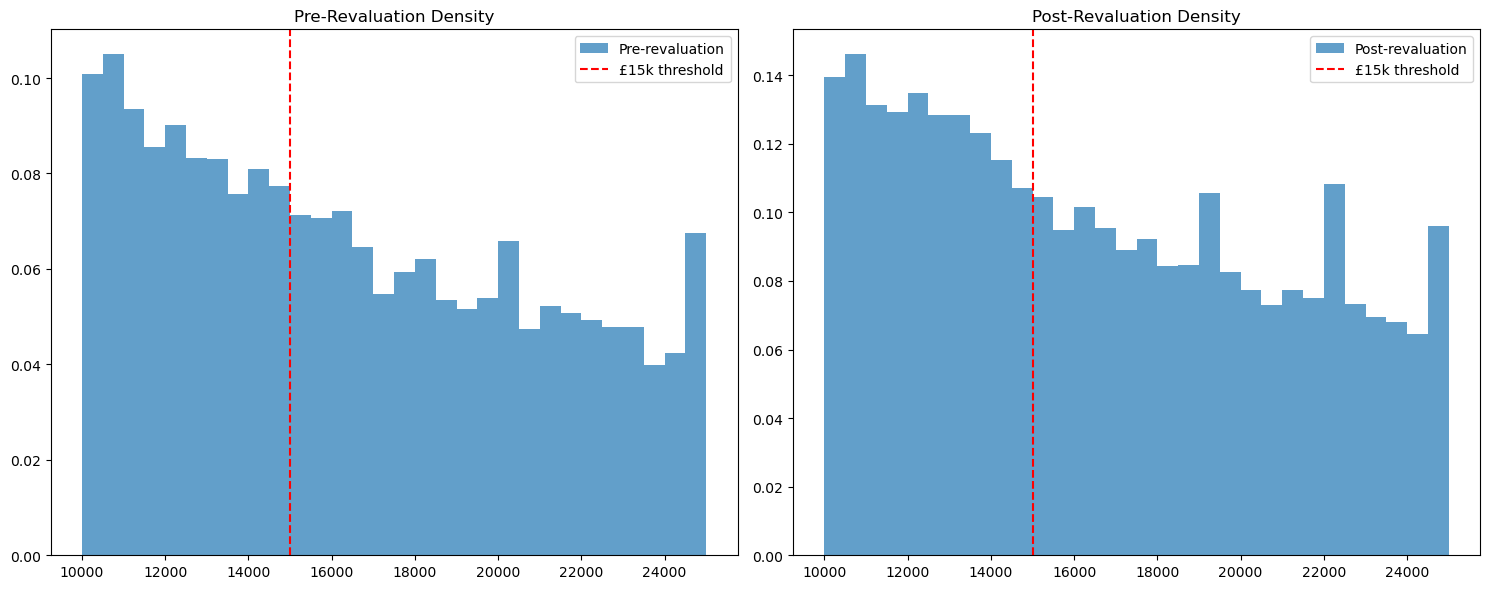

Bunching model error: Error evaluating factor: NameError: name 'density' is not defined
    density ~ post_2017 * threshold_15k +                           C(timepoint) + C(rv_bin) - 1
    ^^^^^^^
Threshold model error: Error evaluating factor: NameError: name 'log_property_count' is not defined
    below_threshold ~ post_2017 * near_threshold +                            log_floor_area + log_property_count +                           C(lsoa21cd) + C(timepoint) - 1
                                                                                               ^^^^^^^^^^^^^^^^^^


In [22]:
results = main_analysis(business17_with_timepoint)